# Function 1: Searching for Contamination Sources
Find the source of radiations in some square area. You can only detect the radiation once you are very close to it, meaning most of the readings will be zero. There are two sources, one is not too dangerous, so make sure you try to find both modes of the function.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel

In [2]:

def load_inputs(file_path):
    with open(file_path, "r") as f:
        content = f.read()

    # Make the file a proper list of lists
    content = "[" + content.replace("]\n[", "],[") + "]"

    # Safe eval with restricted globals
    return eval(content, {"array": np.array})


def load_outputs(file_path):
    with open(file_path, "r") as f:
        content = f.read()

    content = "[" + content.replace("]\n[", "],[") + "]"

    return eval(content, {"np": np})


def get_input_points(function_number, file_path="../inputs.txt"):
    if not 1 <= function_number <= 8:
        raise ValueError("Function number must be between 1 and 8")

    data = load_inputs(file_path)
    index = function_number - 1

    inputs = [dataset[index] for dataset in data]
    return np.array(inputs)


def get_output_points(function_number, file_path="../outputs.txt"):
    if not 1 <= function_number <= 8:
        raise ValueError("Function number must be between 1 and 8")

    data = load_outputs(file_path)
    index = function_number - 1

    outputs = [row[index] for row in data]
    return np.array(outputs)

# Load inputs
X = np.load(r'initial_inputs.npy')
y = np.load(r'initial_outputs.npy')

# Get input and outputs from submissions
inputs_array = get_input_points(1)
outputs_array = get_output_points(1)

# Append inputs_f1_array to X
X = np.vstack((X, inputs_array))

# Append outputs_f1_array to Y
y = np.hstack((y, outputs_array))

print("New shape of X:", X.shape)
print("New shape of Y:", y.shape)

New shape of X: (19, 2)
New shape of Y: (19,)


Using Bayesian Optimisation and considering an Upper Confidence Bound acquisition function. Surrogate Model: A probabilistic model (Gaussian Process) that approximates the objective function.

In [3]:
kernel = ConstantKernel(1.0) * RBF(length_scale=0.02, length_scale_bounds=(1e-6, 1.0))
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-5, normalize_y=True)
gp.fit(X, y)

GaussianProcessRegressor(alpha=1e-05, kernel=1**2 * RBF(length_scale=0.02),
                         normalize_y=True)

In [4]:
n_candidates = 10000  # large number of candidate points
candidates = np.random.uniform(0, 1, size=(n_candidates, X.shape[1]))  # 2D in this case

# Upper Confidence Bound acquisition
def ucb(X_candidate, model, kappa=2.0):
    mean, std = model.predict(X_candidate, return_std=True)
    return mean + kappa * std

global_candidates = np.random.uniform(0, 1, size=(5000, 2))

# Local candidates (high importance)
best_idx = np.argmax(y)
best_point = X[best_idx]
local_candidates = best_point + np.random.uniform(-0.005, 0.005, size=(5000, 2))
local_candidates = np.clip(local_candidates, 0, 1)

# Combine
candidates = np.vstack([global_candidates, local_candidates])

acq_values = ucb(candidates, gp, kappa=0.7)
next_point = candidates[np.argmax(acq_values)]

formatted_next_query = f"{next_point[0]:.6f}-{next_point[1]:.6f}"

print("Next Query Point:", formatted_next_query)

Next Query Point: 0.650574-0.665606


To optimize the acquisition function, we will simply use gridsearch over a space of 10,000 grid points

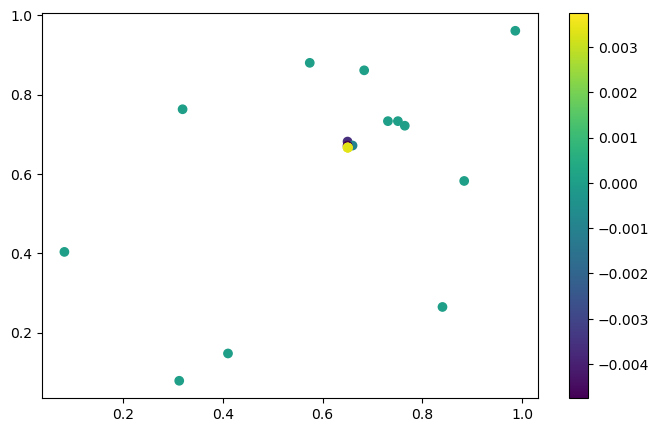

In [5]:
# Define grid of points
# We know the input is in the range 0.000000 to 0.999999
x1 = np.linspace(0.000000, .999999, 100)  # Assuming the search space is within [0, 1] for both dimensions
# We know the input is in the range 0.000000 to 0.999999
x2 = np.linspace(0.000000, .999999, 100)
X_grid = np.array(np.meshgrid(x1, x2)).reshape(2, -1).T

fig, ax = plt.subplots()
fig.set_figheight(5)
fig.set_figwidth(8)
plt.scatter(X[:, 0], X[:, 1], c = y)
plt.colorbar()